In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv("data/processed/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

risk_results = []

for code, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    if len(returns) > 30:

        var95 = np.percentile(
            returns,
            5
        )

        cvar95 = returns[
            returns <= var95
        ].mean()

        risk_results.append([
            code,
            var95,
            cvar95
        ])

risk_df = pd.DataFrame(
    risk_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

risk_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/02_nav_history.csv'

In [ ]:
risk_df.to_csv(
    "var_cvar_report.csv",
    index=False
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

top_funds = (
    nav["amfi_code"]
    .drop_duplicates()
    .head(5)
)

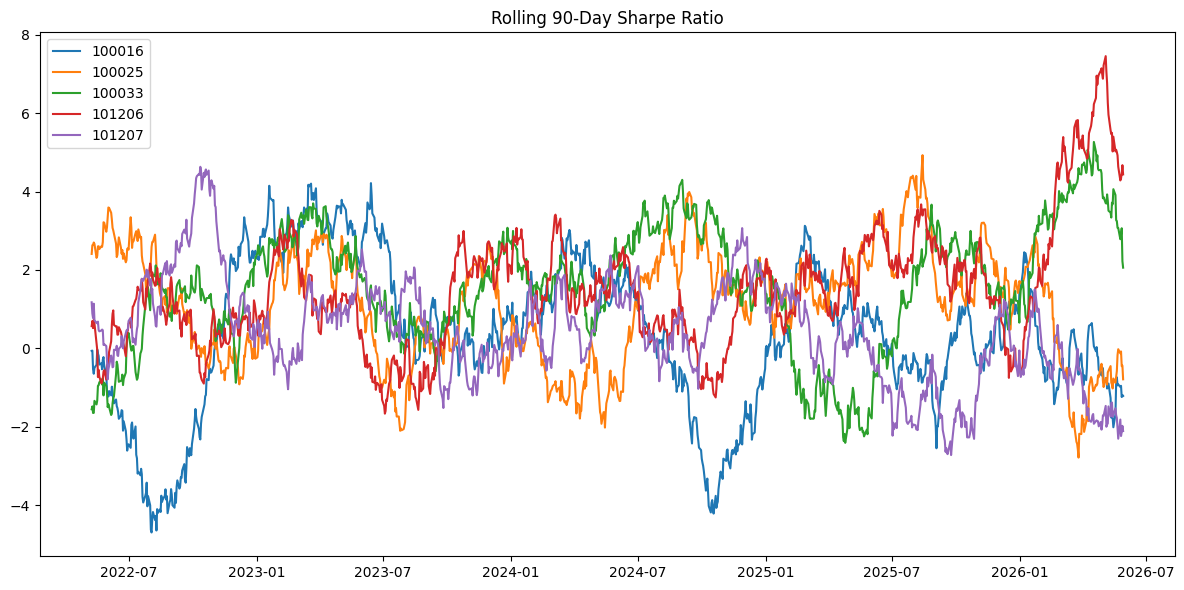

In [ ]:
plt.figure(figsize=(12,6))

for fund in top_funds:

    df = nav[
        nav["amfi_code"] == fund
    ].copy()

    sharpe = (
        df["daily_return"]
        .rolling(90)
        .mean()
        /
        df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        sharpe,
        label=str(fund)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.tight_layout()

plt.savefig(
    "rolling_sharpe_chart.png"
)

plt.show()

In [ ]:
investor = pd.read_csv(
    "data/processed/08_investor_transactions.csv"
)

investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

investor = investor.sort_values(
    ["investor_id","transaction_date"]
)

investor["gap_days"] = (
    investor.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

sip_gap = (
    investor.groupby("investor_id")
    ["gap_days"]
    .mean()
    .reset_index()
)

sip_gap["status"] = np.where(
    sip_gap["gap_days"] > 35,
    "At Risk",
    "Healthy"
)

sip_gap.head()

,investor_id,gap_days,status
0,INV000001,38.000,At Risk
1,INV000002,82.800,At Risk
2,INV000003,238.000,At Risk
3,INV000004,53.375,At Risk
4,INV000005,52.000,At Risk


In [ ]:
investor["first_txn"] = (
    investor.groupby("investor_id")
    ["transaction_date"]
    .transform("min")
)

investor["cohort"] = (
    investor["first_txn"]
    .dt.to_period("M")
)

cohort_df = (
    investor.groupby("cohort")
    .agg(
        investors=("investor_id","nunique"),
        amount=("amount_inr","sum")
    )
)

cohort_df

,investors,amount
cohort,,
2024-01,1577,1378531351
2024-02,990,837486576
2024-03,669,481918027
2024-04,441,293281266
2024-05,294,171335115
2024-06,236,124582926
2024-07,175,69399857
2024-08,135,56349666
2024-09,100,29532841


In [ ]:
portfolio = pd.read_csv(
    "data/processed/09_portfolio_holdings.csv"
)

hhi_results = []

for code, grp in portfolio.groupby(
    "amfi_code"
):

    weights = (
        grp["weight_pct"] / 100
    )

    hhi = (
        weights ** 2
    ).sum()

    hhi_results.append([
        code,
        hhi
    ])

hhi_df = pd.DataFrame(
    hhi_results,
    columns=[
        "amfi_code",
        "HHI"
    ]
)

hhi_df.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [ ]:
funds = pd.read_csv(
    "data/processed/07_scheme_performance.csv"
)

print(funds.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [ ]:
funds = pd.read_csv(
    "data/processed/07_scheme_performance.csv"
)

def recommend_funds(risk):

    return (
        funds[
            funds["risk_grade"] == risk
        ]
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        [
            [
                "scheme_name",
                "fund_house",
                "risk_grade",
                "sharpe_ratio",
                "return_3yr_pct",
                "aum_crore"
            ]
        ]
        .head(3)
    )

recommend_funds("Moderate")

,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct,aum_crore
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate,1.06,14.84,6434
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,1.06,14.81,11361
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Moderate,1.03,14.41,41553


In [ ]:
recommend_funds(
    "Moderate"
).to_csv(
    "recommender.csv",
    index=False
)

In [ ]:
print("Highest Sharpe Ratio Fund")
print(
    funds.sort_values(
        "sharpe_ratio",
        ascending=False
    )[
        [
            "scheme_name",
            "sharpe_ratio"
        ]
    ].head(1)
)

print("\nHighest Return Fund")
print(
    funds.sort_values(
        "return_5yr_pct",
        ascending=False
    )[
        [
            "scheme_name",
            "return_5yr_pct"
        ]
    ].head(1)
)

print("\nLowest Risk Fund")
print(
    funds.sort_values(
        "std_dev_ann_pct"
    )[
        [
            "scheme_name",
            "std_dev_ann_pct"
        ]
    ].head(1)
)

Highest Sharpe Ratio Fund
                                 scheme_name  sharpe_ratio
14  ICICI Pru Liquid Fund - Regular - Growth          7.68

Highest Return Fund
                               scheme_name  return_5yr_pct
29  ABSL Small Cap Fund - Regular - Growth            23.8

Lowest Risk Fund
                                 scheme_name  std_dev_ann_pct
14  ICICI Pru Liquid Fund - Regular - Growth              0.5


In [ ]:
import os

for f in [
    "var_cvar_report.csv",
    "recommender.csv",
    "rolling_sharpe_chart.png"
]:
    print(f, os.path.exists(f))

var_cvar_report.csv True
recommender.csv True
rolling_sharpe_chart.png True
